# Метод роя частиц для задачи поиска минимума

В ноутбуке реализован PSO для задачи

\[
J(x) \to \min, \qquad g_i(x) \le 0.
\]

Код написан так, чтобы было удобно менять целевую функцию, ограничения и параметры алгоритма. Все файлы, которые создаёт ноутбук, сохраняются в папке задания: `graphs/`, `build/`, `results_pso.csv`, `report_pso.tex`.

## Демонстрационная задача

Для наглядной проверки выбран двумерный пример:

\[
J(x,y)=(x-1.2)^2+(y+1.4)^2+0.35\sin(2x)\cos(3y),
\]

с ограничениями

\[
g_1(x,y)=x^2+y^2-9\le 0,\qquad
 g_2(x,y)=-x-y-2\le 0,\qquad
 g_3(x,y)=x-2.5\le 0.
\]

В коде также есть место для ограничений типа равенства `h_j(x)=0`; в текущем примере они не используются, чтобы допустимая область оставалась двумерной и её можно было показать на графике.

In [1]:
from pathlib import Path
import math
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "pso_mplconfig"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

TASK_DIR_NAME = "Метод роя частиц для решения задачи поиска минимума"

def find_task_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if base.name == TASK_DIR_NAME and (base / "task.md").exists():
            return base
        candidate = base / TASK_DIR_NAME
        if (candidate / "task.md").exists():
            return candidate
    return Path.cwd()

TASK_DIR = find_task_dir()
GRAPHS_DIR = TASK_DIR / "graphs"
BUILD_DIR = TASK_DIR / "build"
GRAPHS_DIR.mkdir(exist_ok=True)
BUILD_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (7.0, 5.2)
plt.rcParams["figure.dpi"] = 140

SEED = 2026
rng = np.random.default_rng(SEED)

In [2]:
def objective(points):
    points = np.asarray(points, dtype=float)
    x = points[..., 0]
    y = points[..., 1]
    return (x - 1.2) ** 2 + (y + 1.4) ** 2 + 0.35 * np.sin(2.0 * x) * np.cos(3.0 * y)


def g1(points):
    points = np.asarray(points, dtype=float)
    x = points[..., 0]
    y = points[..., 1]
    return x**2 + y**2 - 9.0


def g2(points):
    points = np.asarray(points, dtype=float)
    x = points[..., 0]
    y = points[..., 1]
    return -x - y - 2.0


def g3(points):
    points = np.asarray(points, dtype=float)
    x = points[..., 0]
    return x - 2.5


INEQUALITY_CONSTRAINTS = [g1, g2, g3]
EQUALITY_CONSTRAINTS = []
BOUNDS = np.array([[-3.2, 3.2], [-3.2, 3.2]], dtype=float)


def constraint_values(points):
    return np.column_stack([g(points) for g in INEQUALITY_CONSTRAINTS])


def equality_values(points):
    if not EQUALITY_CONSTRAINTS:
        return np.zeros((len(np.atleast_2d(points)), 0))
    return np.column_stack([h(points) for h in EQUALITY_CONSTRAINTS])


def feasible_mask(points, eq_tol=1e-5):
    pts = np.atleast_2d(points)
    in_bounds = np.all((pts >= BOUNDS[:, 0]) & (pts <= BOUNDS[:, 1]), axis=1)
    ineq_ok = np.all(constraint_values(pts) <= 1e-10, axis=1)
    eq_ok = np.all(np.abs(equality_values(pts)) <= eq_tol, axis=1)
    return in_bounds & ineq_ok & eq_ok


def penalty_value(points, eq_tol=1e-5):
    pts = np.atleast_2d(points)
    ineq_penalty = np.maximum(constraint_values(pts), 0.0) ** 2
    eq_penalty = np.maximum(np.abs(equality_values(pts)) - eq_tol, 0.0) ** 2
    bound_low = np.maximum(BOUNDS[:, 0] - pts, 0.0) ** 2
    bound_high = np.maximum(pts - BOUNDS[:, 1], 0.0) ** 2
    return ineq_penalty.sum(axis=1) + eq_penalty.sum(axis=1) + bound_low.sum(axis=1) + bound_high.sum(axis=1)


def sample_feasible(n, rng, max_attempts=100_000):
    samples = []
    attempts = 0
    while len(samples) < n and attempts < max_attempts:
        batch = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(max(4 * n, 100), BOUNDS.shape[0]))
        ok = feasible_mask(batch)
        samples.extend(batch[ok].tolist())
        attempts += len(batch)
    if len(samples) < n:
        raise RuntimeError("Не удалось набрать допустимые начальные частицы")
    return np.array(samples[:n], dtype=float)

## Параметры PSO

Коэффициенты `alpha_1`, `alpha_2`, `alpha_3` соответствуют инерционной, когнитивной и социальной компонентам. Их сумма равна 1, как требуется в задании.

In [3]:
PSO_PARAMS = {
    "population_size": 36,
    "max_iter": 130,
    "alpha1": 0.55,
    "alpha2": 0.25,
    "alpha3": 0.20,
    "max_velocity_fraction": 0.18,
    "reflection": 0.65,
    "tol_fun": 1e-9,
    "tol_position": 2e-4,
    "patience": 25,
}

assert abs(PSO_PARAMS["alpha1"] + PSO_PARAMS["alpha2"] + PSO_PARAMS["alpha3"] - 1.0) < 1e-12

In [4]:
def pso_optimize(params, seed=SEED):
    rng = np.random.default_rng(seed)
    n_particles = params["population_size"]
    dim = BOUNDS.shape[0]
    span = BOUNDS[:, 1] - BOUNDS[:, 0]
    vmax = params["max_velocity_fraction"] * span

    positions = sample_feasible(n_particles, rng)
    velocities = rng.uniform(-vmax, vmax, size=(n_particles, dim))
    values = objective(positions)

    personal_best = positions.copy()
    personal_best_values = values.copy()
    best_idx = int(np.argmin(values))
    global_best = positions[best_idx].copy()
    global_best_value = float(values[best_idx])

    positions_history = [positions.copy()]
    values_history = [values.copy()]
    best_history = [global_best_value]
    stop_reason = "max_iter"

    for iteration in range(1, params["max_iter"] + 1):
        r2 = rng.random((n_particles, dim))
        r3 = rng.random((n_particles, dim))
        new_velocities = (
            params["alpha1"] * velocities
            + params["alpha2"] * r2 * (personal_best - positions)
            + params["alpha3"] * r3 * (global_best - positions)
        )
        new_velocities = np.clip(new_velocities, -vmax, vmax)
        candidates = positions + new_velocities

        for i in range(n_particles):
            candidates[i] = np.clip(candidates[i], BOUNDS[:, 0], BOUNDS[:, 1])
            if feasible_mask(candidates[i : i + 1])[0]:
                continue

            reflected_velocity = -params["reflection"] * new_velocities[i]
            reflected = np.clip(positions[i] + reflected_velocity, BOUNDS[:, 0], BOUNDS[:, 1])
            if feasible_mask(reflected[None, :])[0]:
                candidates[i] = reflected
                new_velocities[i] = reflected_velocity
            else:
                candidates[i] = positions[i]
                new_velocities[i] = np.zeros(dim)

        positions = candidates
        velocities = new_velocities
        values = objective(positions)

        improved = values < personal_best_values
        personal_best[improved] = positions[improved]
        personal_best_values[improved] = values[improved]

        best_idx = int(np.argmin(personal_best_values))
        if personal_best_values[best_idx] < global_best_value:
            global_best_value = float(personal_best_values[best_idx])
            global_best = personal_best[best_idx].copy()

        positions_history.append(positions.copy())
        values_history.append(values.copy())
        best_history.append(global_best_value)

        if iteration >= params["patience"]:
            recent_change = abs(best_history[-params["patience"]] - best_history[-1])
            swarm_radius = float(np.max(np.std(positions, axis=0)))
            if recent_change < params["tol_fun"]:
                stop_reason = "criterion_change"
                break
            if swarm_radius < params["tol_position"]:
                stop_reason = "particle_positions"
                break

    return {
        "best_position": global_best,
        "best_value": global_best_value,
        "positions_history": np.array(positions_history),
        "values_history": np.array(values_history),
        "best_history": np.array(best_history),
        "iterations": len(best_history) - 1,
        "stop_reason": stop_reason,
    }


result = pso_optimize(PSO_PARAMS)
result["best_position"], result["best_value"], result["iterations"], result["stop_reason"]

(array([ 1.04438755, -1.19916643]),
 -0.2084794119957341,
 35,
 'particle_positions')

In [5]:
def grid_reference(n=520):
    x = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], n)
    y = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], n)
    X, Y = np.meshgrid(x, y)
    pts = np.column_stack([X.ravel(), Y.ravel()])
    mask = feasible_mask(pts)
    vals = np.full(len(pts), np.nan)
    vals[mask] = objective(pts[mask])
    best_idx = int(np.nanargmin(vals))
    return pts[best_idx], float(vals[best_idx])


grid_best_position, grid_best_value = grid_reference()
summary = pd.DataFrame([
    {
        "method": "PSO",
        "x_best": result["best_position"][0],
        "y_best": result["best_position"][1],
        "J_best": result["best_value"],
        "iterations": result["iterations"],
        "stop_reason": result["stop_reason"],
    },
    {
        "method": "dense_grid_reference",
        "x_best": grid_best_position[0],
        "y_best": grid_best_position[1],
        "J_best": grid_best_value,
        "iterations": np.nan,
        "stop_reason": "reference",
    },
])
summary.to_csv(TASK_DIR / "results_pso.csv", index=False)
summary

,method,x_best,y_best,J_best,iterations,stop_reason
0,PSO,1.044388,-1.199166,-0.208479,35.0,particle_positions
1,dense_grid_reference,1.042004,-1.202312,-0.208445,NaN,reference


## Визуализация

Ниже строятся требуемые графики:

1. линии уровня функционала и ограничений с траекториями частиц;
2. зависимость `J(x_best)` от итерации;
3. поверхность `J(x_k^l)` по номеру итерации и номеру частицы;
4. 3D-картина стягивания частиц в фазовом пространстве `(x, y, J(x,y))`.

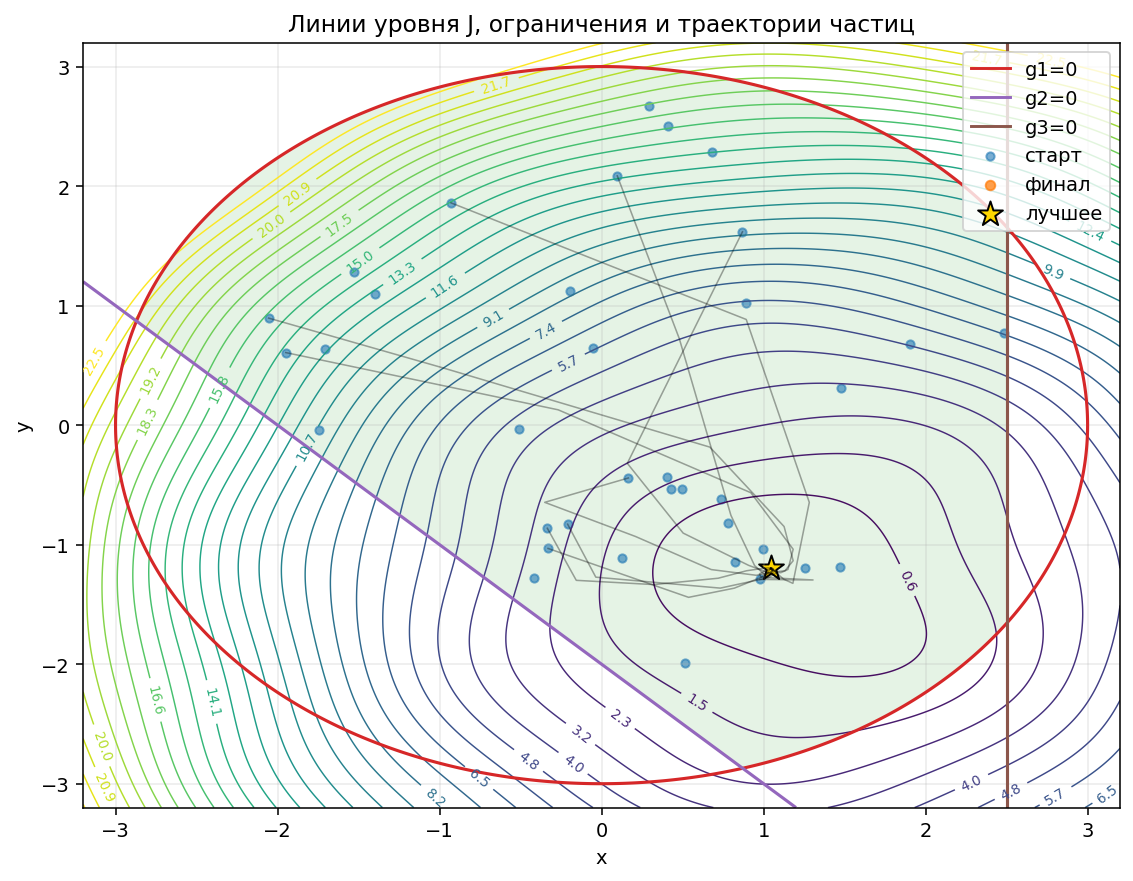

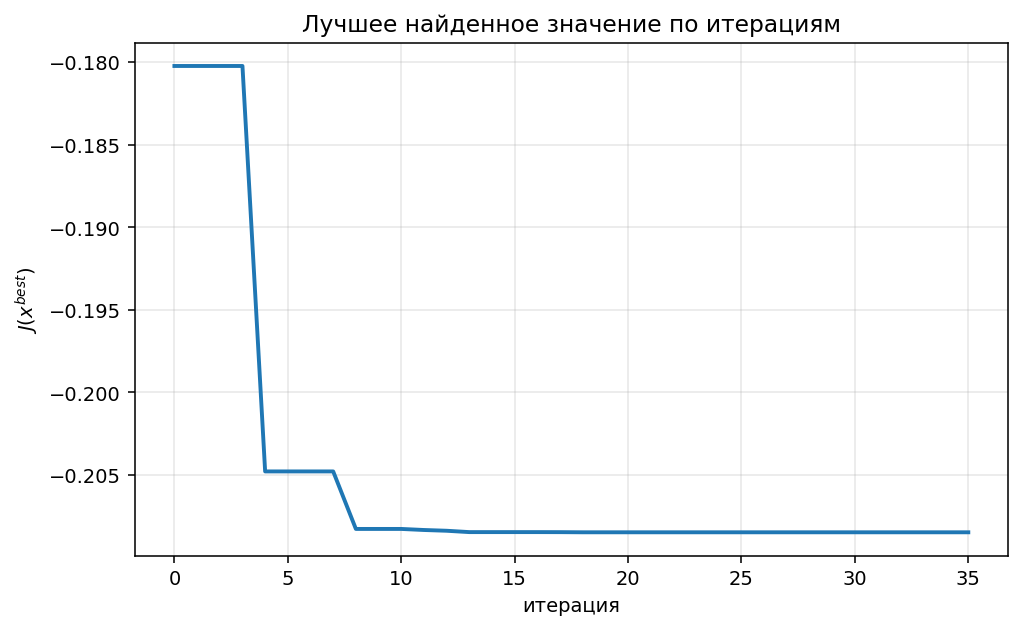

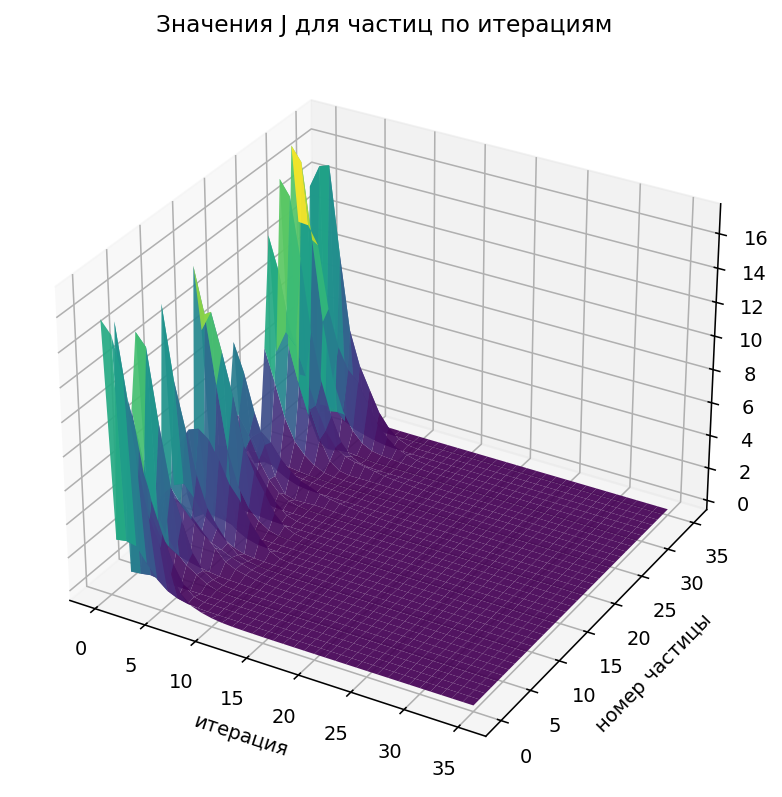

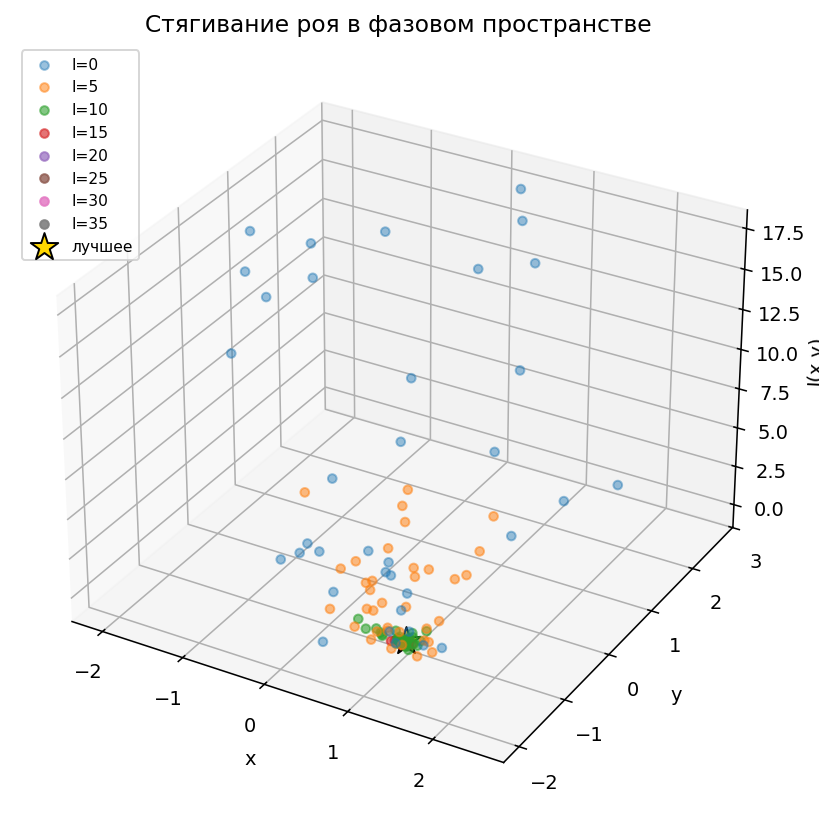

In [6]:
def make_grid(n=420):
    x = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], n)
    y = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], n)
    X, Y = np.meshgrid(x, y)
    pts = np.stack([X, Y], axis=-1)
    Z = objective(pts)
    G = [g(pts) for g in INEQUALITY_CONSTRAINTS]
    feasible = feasible_mask(pts.reshape(-1, 2)).reshape(X.shape)
    return X, Y, Z, G, feasible


def plot_contours_and_trajectories(result):
    X, Y, Z, G, feasible = make_grid()
    fig, ax = plt.subplots(figsize=(8.2, 6.4))
    levels = np.linspace(np.nanmin(Z), np.nanpercentile(Z, 92), 28)
    cs = ax.contour(X, Y, Z, levels=levels, linewidths=0.75)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")
    ax.contourf(X, Y, feasible, levels=[0.5, 1.5], alpha=0.12, colors=["tab:green"])
    colors = ["tab:red", "tab:purple", "tab:brown"]
    labels = ["g1=0", "g2=0", "g3=0"]
    for gvals, color, label in zip(G, colors, labels):
        ax.contour(X, Y, gvals, levels=[0.0], colors=[color], linewidths=1.6)
        ax.plot([], [], color=color, label=label)

    positions = result["positions_history"]
    every = max(1, len(positions) // 12)
    for particle in range(min(10, positions.shape[1])):
        path = positions[::every, particle, :]
        ax.plot(path[:, 0], path[:, 1], color="black", alpha=0.35, linewidth=0.8)
    ax.scatter(positions[0, :, 0], positions[0, :, 1], s=18, alpha=0.6, label="старт")
    ax.scatter(positions[-1, :, 0], positions[-1, :, 1], s=24, alpha=0.75, label="финал")
    ax.scatter([result["best_position"][0]], [result["best_position"][1]], marker="*", s=180, color="gold", edgecolor="black", label="лучшее")
    ax.set_title("Линии уровня J, ограничения и траектории частиц")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(BOUNDS[0])
    ax.set_ylim(BOUNDS[1])
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    fig.tight_layout()
    path = GRAPHS_DIR / "pso_contours_trajectories.png"
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)


def plot_best_history(result):
    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    ax.plot(result["best_history"], linewidth=2)
    ax.set_title("Лучшее найденное значение по итерациям")
    ax.set_xlabel("итерация")
    ax.set_ylabel(r"$J(x^{best})$")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path = GRAPHS_DIR / "pso_best_history.png"
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)


def plot_particle_value_surface(result):
    values = result["values_history"]
    iteration_idx = np.arange(values.shape[0])
    particle_idx = np.arange(values.shape[1])
    I, P = np.meshgrid(iteration_idx, particle_idx, indexing="ij")
    fig = plt.figure(figsize=(8.2, 5.8))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(I, P, values, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
    ax.set_title("Значения J для частиц по итерациям")
    ax.set_xlabel("итерация")
    ax.set_ylabel("номер частицы")
    ax.set_zlabel("J")
    fig.tight_layout()
    path = GRAPHS_DIR / "pso_particle_value_surface.png"
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)


def plot_swarm_3d(result):
    positions = result["positions_history"]
    selected = np.unique(np.linspace(0, positions.shape[0] - 1, 8, dtype=int))
    fig = plt.figure(figsize=(8.0, 6.0))
    ax = fig.add_subplot(111, projection="3d")
    for idx in selected:
        pts = positions[idx]
        vals = objective(pts)
        ax.scatter(pts[:, 0], pts[:, 1], vals, s=20, alpha=0.45 + 0.45 * idx / max(1, positions.shape[0] - 1), label=f"l={idx}")
    ax.scatter([result["best_position"][0]], [result["best_position"][1]], [result["best_value"]], marker="*", s=220, color="gold", edgecolor="black", label="лучшее")
    ax.set_title("Стягивание роя в фазовом пространстве")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("J(x,y)")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    path = GRAPHS_DIR / "pso_swarm_3d.png"
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)


plot_contours_and_trajectories(result)
plot_best_history(result)
plot_particle_value_surface(result)
plot_swarm_3d(result)

## Отчёт

Следующая ячейка сохраняет LaTeX-отчёт. PDF собирается из файла `report_pso.tex`.

In [7]:
stop_reason_tex = result["stop_reason"].replace("_", r"\_")

report_tex = rf"""
\documentclass[12pt,a4paper]{{article}}
\usepackage[T2A]{{fontenc}}
\usepackage[utf8]{{inputenc}}
\usepackage[russian]{{babel}}
\usepackage{{amsmath,amssymb}}
\usepackage{{geometry}}
\usepackage{{graphicx}}
\usepackage{{float}}
\usepackage{{booktabs}}
\geometry{{margin=2.2cm}}

\title{{Метод роя частиц для поиска минимума}}
\author{{}}
\date{{июнь 2026}}

\begin{{document}}
\maketitle

\section*{{Постановка}}
Реализован алгоритм Particle Swarm Optimization для задачи
\[
J(x)\to\min,\qquad g_i(x)\le 0.
\]
В качестве демонстрационного примера использована двумерная задача
\[
J(x,y)=(x-1.2)^2+(y+1.4)^2+0.35\sin(2x)\cos(3y),
\]
\[
g_1=x^2+y^2-9\le 0,\qquad
 g_2=-x-y-2\le 0,\qquad
 g_3=x-2.5\le 0.
\]

\section*{{Алгоритм}}
На каждой итерации скорость частицы обновлялась по формуле
\[
v_k^{{l+1}}=\alpha_1v_k^l+\alpha_2r_2(x_k^{{best}}-x_k^l)+\alpha_3r_3(x^{{best}}-x_k^l),
\]
где $r_2,r_3\sim U[0,1]$. Затем вычислялось новое положение $x_k^{{l+1}}=x_k^l+v_k^{{l+1}}$.
Если новое положение нарушало ограничения, сначала выполнялось отражение скорости. Если отражённая точка также была недопустимой, частица оставалась в предыдущей допустимой позиции.

\section*{{Параметры}}
\begin{{center}}
\begin{{tabular}}{{lr}}
\toprule
Параметр & Значение \\
\midrule
Число частиц & {PSO_PARAMS['population_size']} \\
Максимум итераций & {PSO_PARAMS['max_iter']} \\
$\alpha_1$ & {PSO_PARAMS['alpha1']} \\
$\alpha_2$ & {PSO_PARAMS['alpha2']} \\
$\alpha_3$ & {PSO_PARAMS['alpha3']} \\
Коэффициент отражения & {PSO_PARAMS['reflection']} \\
\bottomrule
\end{{tabular}}
\end{{center}}

\section*{{Результат}}
\begin{{center}}
\begin{{tabular}}{{lrrrl}}
\toprule
Метод & $x$ & $y$ & $J(x,y)$ & останов \\
\midrule
PSO & {result['best_position'][0]:.6f} & {result['best_position'][1]:.6f} & {result['best_value']:.6f} & {stop_reason_tex} \\
Сеточная проверка & {grid_best_position[0]:.6f} & {grid_best_position[1]:.6f} & {grid_best_value:.6f} & reference \\
\bottomrule
\end{{tabular}}
\end{{center}}
Алгоритм выполнил {result['iterations']} итераций. Сеточная проверка приведена только как ориентир для двумерного примера.

\section*{{Графики}}
\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{graphs/pso_contours_trajectories.png}}
\caption{{Линии уровня функционала, границы ограничений и траектории частиц.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.82\textwidth]{{graphs/pso_best_history.png}}
\caption{{Изменение лучшего найденного значения $J(x^{{best}})$ по итерациям.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{graphs/pso_particle_value_surface.png}}
\caption{{Поверхность значений $J(x_k^l)$ по номеру итерации и номеру частицы.}}
\end{{figure}}

\begin{{figure}}[H]
\centering
\includegraphics[width=0.9\textwidth]{{graphs/pso_swarm_3d.png}}
\caption{{Стягивание частиц в фазовом пространстве $(x,y,J)$.}}
\end{{figure}}

\section*{{Вывод}}
Метод роя частиц устойчиво нашёл допустимую точку минимума. Механизм отражения не допускает ухода частиц за границы области, а графики показывают сходимость лучшего значения и концентрацию роя около найденного экстремума.

\end{{document}}
"""

report_path = TASK_DIR / "report_pso.tex"
report_path.write_text(report_tex, encoding="utf-8")
print(report_path)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/8 семестр/Optimization Methods/Метод роя частиц для решения задачи поиска минимума/report_pso.tex
